In [2]:
from google.colab import drive
drive.mount('/content/drive/')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
EVAL_DATA_ROOT = "/content/drive/MyDrive/authentic_split_cv_eval"
MODEL_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/model1/winner_config6_lr3e-05_lay60_drop0p3_0p6"
OUTPUT_DIR = "/content/drive/MyDrive/authentic_training_cv_eval/model1_analysis"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = ["t72", "t80", "t90"]
NUM_FOLDS = 5
IMG_SIZE = (682, 1024)
BATCH_SIZE = 4

print(f"Eval data: {EVAL_DATA_ROOT}")
print(f"Model folder: {MODEL_DIR}")
print(f"Output folder: {OUTPUT_DIR}")

Eval data: /content/drive/MyDrive/authentic_split_cv_eval
Model folder: /content/drive/MyDrive/authentic_training_cv_eval/model1/winner_config6_lr3e-05_lay60_drop0p3_0p6
Output folder: /content/drive/MyDrive/authentic_training_cv_eval/model1_analysis


In [6]:
# Load each fold, predict, and compute fold metrics
per_fold_predictions = {}
per_fold_metrics = {}

for fold_idx in range(NUM_FOLDS):
    print(f"\n--- Fold {fold_idx} ---")
    model_path = os.path.join(MODEL_DIR, f"model_fold{fold_idx}.keras")
    test_dir = os.path.join(EVAL_DATA_ROOT, f"fold_{fold_idx}", "test")

    if not os.path.exists(model_path):
        print(f"Missing model: {model_path}")
        continue
    if not os.path.exists(test_dir):
        print(f"Missing test data: {test_dir}")
        continue

    model = keras.models.load_model(model_path)

    test_ds = keras.utils.image_dataset_from_directory(
        test_dir,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False,
        crop_to_aspect_ratio=True,
    )

    y_true = []
    y_pred = []
    for batch_imgs, batch_labels in test_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(batch_labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    per_fold_predictions[fold_idx] = (y_true, y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=0)
    macro_prec = precision_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=0)

    per_fold_metrics[fold_idx] = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
    }

    print(
        f"Fold {fold_idx} metrics: accuracy={acc:.4f}, "
        f"macro_f1={macro_f1:.4f}, precision={macro_prec:.4f}, recall={macro_rec:.4f}"
    )

    del model
    keras.backend.clear_session()

print("All folds processed.")


--- Fold 0 ---
Found 171 files belonging to 3 classes.
Fold 0 metrics: accuracy=0.8830, macro_f1=0.8715, precision=0.8667, recall=0.8768

--- Fold 1 ---
Found 171 files belonging to 3 classes.
Fold 1 metrics: accuracy=0.8830, macro_f1=0.8656, precision=0.8888, recall=0.8487

--- Fold 2 ---
Found 172 files belonging to 3 classes.
Fold 2 metrics: accuracy=0.8663, macro_f1=0.8541, precision=0.8544, recall=0.8559

--- Fold 3 ---
Found 171 files belonging to 3 classes.
Fold 3 metrics: accuracy=0.8421, macro_f1=0.8193, precision=0.8194, recall=0.8220

--- Fold 4 ---
Found 171 files belonging to 3 classes.
Fold 4 metrics: accuracy=0.8772, macro_f1=0.8589, precision=0.8539, recall=0.8681
All folds processed.


In [7]:
# Aggregate per-fold metrics and save summary
metrics_df = pd.DataFrame(per_fold_metrics).T
metrics_df.index.name = "fold"

print("\nPer-fold metrics:")
print(metrics_df.to_string())

print("\nAggregated metrics:")
print(f"Accuracy       {metrics_df['accuracy'].mean():.4f} ± {metrics_df['accuracy'].std():.4f}")
print(f"Macro F1       {metrics_df['macro_f1'].mean():.4f} ± {metrics_df['macro_f1'].std():.4f}")
print(f"Macro Precision{metrics_df['macro_precision'].mean():.4f} ± {metrics_df['macro_precision'].std():.4f}")
print(f"Macro Recall   {metrics_df['macro_recall'].mean():.4f} ± {metrics_df['macro_recall'].std():.4f}")

metrics_df.to_csv(os.path.join(OUTPUT_DIR, "per_fold_metrics.csv"))
print(f"Saved per-fold metrics to: {OUTPUT_DIR}/per_fold_metrics.csv")


Per-fold metrics:
      accuracy  macro_f1  macro_precision  macro_recall
fold                                                   
0     0.883041  0.871491         0.866699      0.876835
1     0.883041  0.865571         0.888828      0.848744
2     0.866279  0.854107         0.854372      0.855910
3     0.842105  0.819350         0.819385      0.821955
4     0.877193  0.858890         0.853865      0.868112

Aggregated metrics:
Accuracy       0.8703 ± 0.0172
Macro F1       0.8539 ± 0.0204
Macro Precision0.8566 ± 0.0252
Macro Recall   0.8543 ± 0.0211
Saved per-fold metrics to: /content/drive/MyDrive/authentic_training_cv_eval/model1_analysis/per_fold_metrics.csv


In [8]:
# Compute class-wise metrics per fold and aggregate them
class_metrics_per_fold = {}

for fold_idx, (y_true, y_pred) in per_fold_predictions.items():
    f1_per_class = f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    prec_per_class = precision_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    rec_per_class = recall_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    support_per_class = [int(np.sum(y_true == i)) for i in range(3)]

    class_metrics_per_fold[fold_idx] = {
        cls: {
            "precision": float(prec_per_class[class_idx]),
            "recall": float(rec_per_class[class_idx]),
            "f1": float(f1_per_class[class_idx]),
            "support": support_per_class[class_idx],
        }
        for class_idx, cls in enumerate(CLASS_NAMES)
    }

print("\nClass-wise aggregated metrics:")
class_aggregate = {}
for cls in CLASS_NAMES:
    precisions = [class_metrics_per_fold[f][cls]["precision"] for f in class_metrics_per_fold]
    recalls = [class_metrics_per_fold[f][cls]["recall"] for f in class_metrics_per_fold]
    f1s = [class_metrics_per_fold[f][cls]["f1"] for f in class_metrics_per_fold]
    supports = [class_metrics_per_fold[f][cls]["support"] for f in class_metrics_per_fold]

    class_aggregate[cls] = {
        "precision_mean": np.mean(precisions),
        "precision_std": np.std(precisions, ddof=1),
        "recall_mean": np.mean(recalls),
        "recall_std": np.std(recalls, ddof=1),
        "f1_mean": np.mean(f1s),
        "f1_std": np.std(f1s, ddof=1),
        "support_total": sum(supports),
    }

    print(
        f"{cls}: precision={class_aggregate[cls]['precision_mean']:.4f} ± {class_aggregate[cls]['precision_std']:.4f}, "
        f"recall={class_aggregate[cls]['recall_mean']:.4f} ± {class_aggregate[cls]['recall_std']:.4f}, "
        f"f1={class_aggregate[cls]['f1_mean']:.4f} ± {class_aggregate[cls]['f1_std']:.4f}, "
        f"support={class_aggregate[cls]['support_total']}"
    )

with open(os.path.join(OUTPUT_DIR, "classwise_metrics.json"), "w") as f:
    json.dump({"per_fold": class_metrics_per_fold, "aggregated": class_aggregate}, f, indent=2)
print(f"Saved class-wise metrics to: {OUTPUT_DIR}/classwise_metrics.json")


Class-wise aggregated metrics:
t72: precision=0.9112 ± 0.0240, recall=0.9039 ± 0.0335, f1=0.9068 ± 0.0121, support=447
t80: precision=0.8472 ± 0.0573, recall=0.8560 ± 0.0433, f1=0.8496 ± 0.0298, support=236
t90: precision=0.8115 ± 0.0415, recall=0.8030 ± 0.0513, f1=0.8053 ± 0.0239, support=173
Saved class-wise metrics to: /content/drive/MyDrive/authentic_training_cv_eval/model1_analysis/classwise_metrics.json


In [9]:
# Create aggregate classification report across folds
all_y_true = []
all_y_pred = []
for fold_idx in sorted(per_fold_predictions):
    y_true, y_pred = per_fold_predictions[fold_idx]
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)

print("\nAggregated classification report:")
report = classification_report(all_y_true, all_y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0)
print(report)

with open(os.path.join(OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)
print(f"Saved classification report to: {OUTPUT_DIR}/classification_report.txt")


Aggregated classification report:
              precision    recall  f1-score   support

         t72     0.9099    0.9038    0.9068       447
         t80     0.8417    0.8559    0.8487       236
         t90     0.8081    0.8035    0.8058       173

    accuracy                         0.8703       856
   macro avg     0.8532    0.8544    0.8538       856
weighted avg     0.8705    0.8703    0.8704       856

Saved classification report to: /content/drive/MyDrive/authentic_training_cv_eval/model1_analysis/classification_report.txt


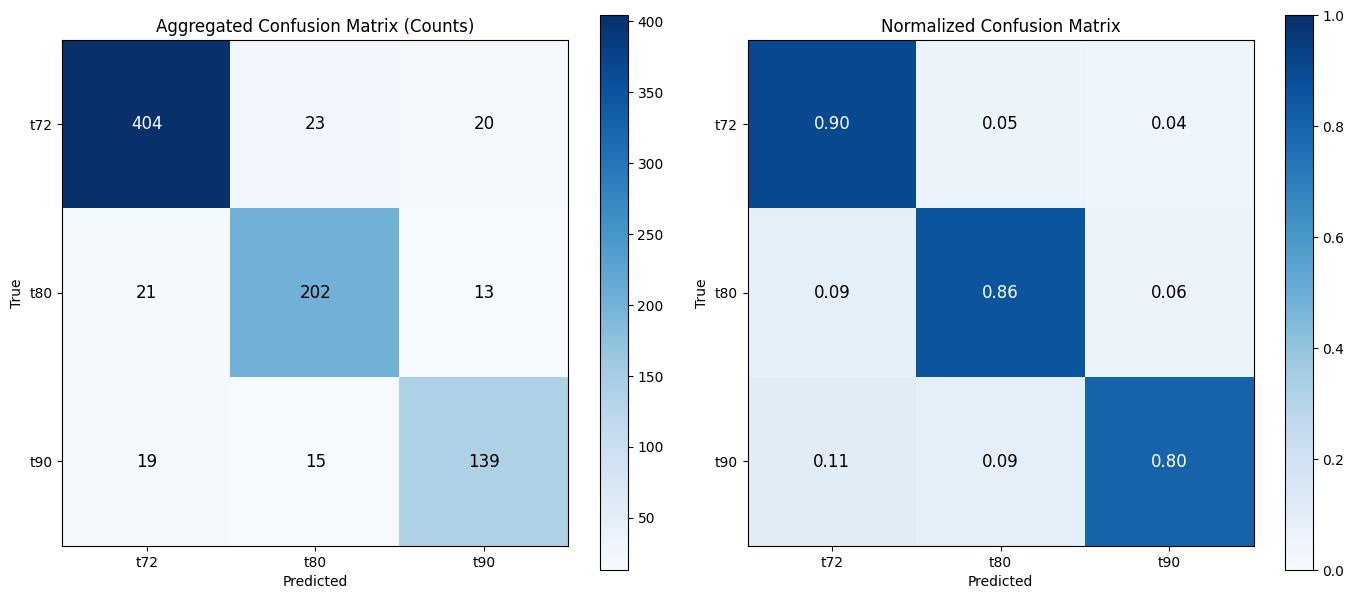

Saved confusion matrix figure to: /content/drive/MyDrive/authentic_training_cv_eval/model1_analysis/aggregated_confusion_matrix.png
Saved confusion matrices summary.


In [10]:
# Create and save aggregated confusion matrices and plots
cm_total = np.zeros((3, 3), dtype=int)
for fold_idx in per_fold_predictions:
    y_true, y_pred = per_fold_predictions[fold_idx]
    cm_total += confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

cm_normalized = cm_total.astype(float) / cm_total.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(cm_total, cmap="Blues")
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title("Aggregated Confusion Matrix (Counts)")
for i in range(3):
    for j in range(3):
        text_color = "white" if cm_total[i, j] > cm_total.max() / 2 else "black"
        axes[0].text(j, i, str(cm_total[i, j]), ha="center", va="center", color=text_color, fontsize=12)
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(CLASS_NAMES)
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_title("Normalized Confusion Matrix")
for i in range(3):
    for j in range(3):
        text_color = "white" if cm_normalized[i, j] > 0.5 else "black"
        axes[1].text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=12)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
conf_mat_path = os.path.join(OUTPUT_DIR, "aggregated_confusion_matrix.png")
plt.savefig(conf_mat_path, dpi=150)
plt.show()
print(f"Saved confusion matrix figure to: {conf_mat_path}")

with open(os.path.join(OUTPUT_DIR, "confusion_matrices.json"), "w") as f:
    json.dump({
        "counts": cm_total.tolist(),
        "normalized": cm_normalized.tolist(),
        "class_names": CLASS_NAMES,
    }, f, indent=2)
print("Saved confusion matrices summary.")


Top misclassifications:
  T72 to T80: 23
  T80 to T72: 21
  T72 to T90: 20
  T90 to T72: 19
  T90 to T80: 15
  T80 to T90: 13


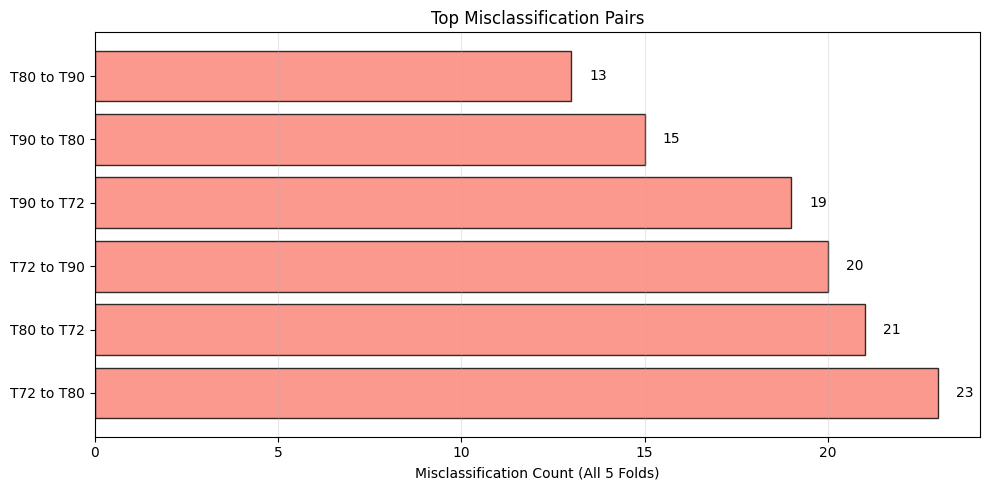

Saved top misclassification plot to: /content/drive/MyDrive/authentic_training_cv_eval/model1_analysis/top_misclassifications.png


In [11]:
# Top misclassification pairs across folds
errors = {
    f"{CLASS_NAMES[i].upper()} to {CLASS_NAMES[j].upper()}": int(cm_total[i, j])
    for i in range(3)
    for j in range(3)
    if i != j
}

sorted_errors = dict(sorted(errors.items(), key=lambda item: -item[1]))
print("\nTop misclassifications:")
for key, val in sorted_errors.items():
    print(f"  {key}: {val}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(sorted_errors.keys()), list(sorted_errors.values()), color="salmon", edgecolor="black", alpha=0.8)
ax.set_xlabel("Misclassification Count (All 5 Folds)")
ax.set_title("Top Misclassification Pairs")
ax.grid(axis="x", alpha=0.3)
for i, (key, val) in enumerate(sorted_errors.items()):
    ax.text(val + 0.5, i, str(val), va="center", fontsize=10)

plt.tight_layout()
misclass_path = os.path.join(OUTPUT_DIR, "top_misclassifications.png")
plt.savefig(misclass_path, dpi=150)
plt.show()
print(f"Saved top misclassification plot to: {misclass_path}")